# 🎬 Anomaly Detection — MP4 Inference (VideoMAE Features)

Uses **MCG-NJU/videomae-base** — the exact same model used during training.

Pipeline:
1. Extract 16-frame clips from the MP4
2. Run each clip through **VideoMAE** → 768-d CLS token
3. Feed feature sequence into your **AnomalyTransformer**
4. Output: prediction + confidence + anomaly timeline

> ✅ Pre-requisite: `best_model.pt` in the same folder as this notebook

# Compatibility Notes

This edited copy is updated for the organized project layout and current laptop environment.

- Original notebooks remain unchanged in `notebooks/`.
- PyTorch 2.6+ checkpoint loading is handled with `weights_only=False` for trusted local checkpoints.
- VideoMAE preprocessing uses `AutoImageProcessor` instead of the deprecated/removed `VideoMAEFeatureExtractor`.
- Paths resolve from the project root so the notebook works even when opened from this subfolder.


In [1]:
from pathlib import Path

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "artifacts").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing artifacts/ and src/")

PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")


Project root: E:\vad_training\vad_project


## Cell 1 — Install Dependencies

In [2]:
import subprocess, sys

pkgs = {
    'torch':         'torch',
    'torchvision':   'torchvision',
    'transformers':  'transformers',
    'opencv-python': 'cv2',
    'Pillow':        'PIL',
    'matplotlib':    'matplotlib',
    'numpy':         'numpy',
    'tqdm':          'tqdm',
    'einops':        'einops',
}
for pkg, imp in pkgs.items():
    try:
        __import__(imp)
        print(f'✅ {pkg}')
    except ImportError:
        print(f'📦 Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
        print(f'✅ {pkg} installed')
print('\n🎉 All ready!')

✅ torch


✅ torchvision


✅ transformers
✅ opencv-python
✅ Pillow


✅ matplotlib
✅ numpy
✅ tqdm
✅ einops

🎉 All ready!


## Cell 2 — Config ⚙️ (Edit Here)

In [3]:
# ─────────────────────────────────────────
# ✏️  ONLY CHANGE THESE
# ─────────────────────────────────────────
VIDEO_PATH  = str(PROJECT_ROOT / 'data' / 'samples' / 'm2-res_270p.mp4')   # Path to your input MP4
CHECKPOINT  = str(PROJECT_ROOT / 'artifacts' / 'checkpoints' / 'best_model.pt')    # Path to trained model checkpoint
THRESHOLD   = 0.3                  # Lowered from 0.5 — more sensitive

# ── VideoMAE clip settings (match your training extraction) ──
CLIP_LEN    = 16      # frames per VideoMAE clip (VideoMAE expects exactly 16)
FRAME_SKIP  = 2       # sample every N frames within each clip (stride)
CLIP_STRIDE = 8       # how many frames to advance between clips (overlap control)
IMG_SIZE    = 224     # VideoMAE input resolution

# ── Must match training notebook exactly ──
FEAT_DIM    = 768
MAX_FRAMES  = 512
NUM_HEADS   = 8
NUM_LAYERS  = 4
FF_DIM      = 1024
DROPOUT     = 0.3

# ── Timeline chart segment size ──
SEGMENT_CLIPS = 4     # group N consecutive clips into one timeline bar
# ─────────────────────────────────────────

import os, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

assert os.path.exists(CHECKPOINT), f'❌ Checkpoint not found: {CHECKPOINT}'
assert os.path.exists(VIDEO_PATH), f'❌ Video not found: {VIDEO_PATH}'
print(f'✅ Checkpoint : {CHECKPOINT}')
print(f'✅ Video      : {VIDEO_PATH}')
print(f'✅ Threshold  : {THRESHOLD}  (anomaly if P(anomaly) >= {THRESHOLD})')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 Laptop GPU
✅ Checkpoint : E:\vad_training\vad_project\artifacts\checkpoints\best_model.pt
✅ Video      : E:\vad_training\vad_project\data\samples\m2-res_270p.mp4
✅ Threshold  : 0.3  (anomaly if P(anomaly) >= 0.3)


## Cell 3 — Load AnomalyTransformer

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)
    def forward(self, x):
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        return x + self.pe(pos)

class AnomalyTransformer(nn.Module):
    def __init__(self, feat_dim=768, d_model=512, num_heads=8,
                 num_layers=4, ff_dim=1024, dropout=0.3, max_frames=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
        )
        self.cls_token   = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        self.pos_enc     = PositionalEncoding(d_model, max_len=max_frames + 1)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers, norm=nn.LayerNorm(d_model)
        )
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 2)
        )
    def forward(self, x):
        B   = x.size(0)
        x   = self.proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_enc(x)
        x   = self.transformer(x)
        return self.head(x[:, 0, :])

model = AnomalyTransformer(
    feat_dim=FEAT_DIM, d_model=512, num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS, ff_dim=FF_DIM, dropout=DROPOUT, max_frames=MAX_FRAMES
).to(DEVICE)

ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'✅ AnomalyTransformer loaded from epoch {ckpt["epoch"]} (Val AUC={ckpt["val_auc"]:.2f}%)')

✅ AnomalyTransformer loaded from epoch 21 (Val AUC=93.25%)


## Cell 4 — Load VideoMAE Feature Extractor

In [5]:
from transformers.models.auto.image_processing_auto import AutoImageProcessor
from transformers.models.videomae.modeling_videomae import VideoMAEModel

VIDEOMAE_NAME = 'MCG-NJU/videomae-base'
print(f'📥 Loading {VIDEOMAE_NAME} from HuggingFace (cached after first download)...')

videomae_extractor = AutoImageProcessor.from_pretrained(VIDEOMAE_NAME)
videomae_model     = VideoMAEModel.from_pretrained(VIDEOMAE_NAME).to(DEVICE)
videomae_model.eval()

print(f'✅ VideoMAE loaded — same model used during training')


@torch.no_grad()
def extract_clip_feature(clip_frames: list) -> np.ndarray:
    """
    clip_frames: list of exactly 16 RGB uint8 numpy arrays (H x W x 3)
    Returns: (768,) float32 — CLS token feature
    """
    inputs = videomae_extractor(clip_frames, return_tensors='pt')
    pixel_values = inputs['pixel_values'].to(DEVICE)   # (1, 16, 3, 224, 224)
    outputs      = videomae_model(pixel_values=pixel_values)
    # Mean-pool all patch tokens → (768,)  — same as typical VideoMAE extraction
    feat = outputs.last_hidden_state[0].mean(dim=0).cpu().numpy()
    return feat.astype(np.float32)


print('✅ Feature extractor ready')

📥 Loading MCG-NJU/videomae-base from HuggingFace (cached after first download)...


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.v_bias           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.value.weight | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.q_bias           | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.query.weight | UNEXPECTED

✅ VideoMAE loaded — same model used during training
✅ Feature extractor ready


## Cell 5 — Extract All Frames from MP4

In [6]:
import cv2
from tqdm.notebook import tqdm

def load_all_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f'❌ Cannot open: {video_path}')

    fps       = cap.get(cv2.CAP_PROP_FPS)
    total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration  = total / fps if fps > 0 else 0
    w         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h         = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f'📹 {os.path.basename(video_path)}')
    print(f'   Resolution : {w}×{h}  |  FPS : {fps:.1f}  |  Duration : {duration:.1f}s  |  Frames : {total}')

    frames = []
    pbar   = tqdm(total=total, desc='Reading frames')
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        pbar.update(1)
    pbar.close()
    cap.release()

    print(f'✅ Loaded {len(frames)} frames')
    return frames, fps, duration


all_frames, fps, duration_s = load_all_frames(VIDEO_PATH)

📹 m2-res_270p.mp4
   Resolution : 480×270  |  FPS : 30.0  |  Duration : 38.4s  |  Frames : 1153


Reading frames:   0%|          | 0/1153 [00:00<?, ?it/s]

✅ Loaded 1153 frames


## Cell 6 — Build 16-Frame Clips & Extract VideoMAE Features

In [7]:
def build_clips(frames, clip_len=16, frame_skip=2, clip_stride=8):
    """
    Build overlapping clips of `clip_len` frames.
    frame_skip  : sample every Nth frame within each clip
    clip_stride : advance this many raw frames between clip starts
    Returns list of (clip_frames, start_frame_idx)
    """
    total    = len(frames)
    span     = clip_len * frame_skip   # raw frames spanned by one clip
    clips    = []
    start    = 0
    while start + span <= total:
        indices = [start + i * frame_skip for i in range(clip_len)]
        clip    = [frames[i] for i in indices]
        clips.append((clip, start))
        start  += clip_stride
    # Handle remaining frames at end
    if start < total and len(clips) == 0:
        # Video too short — pad with last frame
        clip = frames + [frames[-1]] * (clip_len - len(frames))
        clips.append((clip[:clip_len], 0))
    return clips


clips = build_clips(all_frames, CLIP_LEN, FRAME_SKIP, CLIP_STRIDE)
print(f'📦 Total clips : {len(clips)}')
print(f'   Each clip   : {CLIP_LEN} frames  (raw stride={FRAME_SKIP})')
print(f'   Clip stride : {CLIP_STRIDE} raw frames between clips')
print(f'\n🔍 Extracting VideoMAE features...')

features    = []   # (num_clips, 768)
clip_times  = []   # start time (seconds) of each clip

for clip_frames, start_idx in tqdm(clips, desc='VideoMAE extraction'):
    feat = extract_clip_feature(clip_frames)   # (768,)
    features.append(feat)
    clip_times.append(start_idx / fps)

features = np.stack(features, axis=0)   # (num_clips, 768)
print(f'\n✅ Feature array shape : {features.shape}  (clips × 768)')
print(f'   Min: {features.min():.4f}  Max: {features.max():.4f}  Mean: {features.mean():.4f}')

📦 Total clips : 141
   Each clip   : 16 frames  (raw stride=2)
   Clip stride : 8 raw frames between clips

🔍 Extracting VideoMAE features...


VideoMAE extraction:   0%|          | 0/141 [00:00<?, ?it/s]


✅ Feature array shape : (141, 768)  (clips × 768)
   Min: -3.1049  Max: 12.9957  Mean: 0.0104


## Cell 7 — Full-Video Prediction

In [8]:
def predict_features(feat_array, model, max_frames=MAX_FRAMES, device=DEVICE, threshold=THRESHOLD):
    T = feat_array.shape[0]
    if T >= max_frames:
        start = (T - max_frames) // 2
        feat  = feat_array[start : start + max_frames]
    else:
        pad  = np.zeros((max_frames - T, feat_array.shape[1]), dtype=np.float32)
        feat = np.concatenate([feat_array, pad], axis=0)

    feat_t = torch.from_numpy(feat).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(feat_t)
        probs  = F.softmax(logits, dim=-1)[0].cpu().numpy()
    return {
        'prob_normal':  float(probs[0]),
        'prob_anomaly': float(probs[1]),
        'prediction':   'ANOMALY' if probs[1] >= threshold else 'NORMAL',
        'confidence':   float(max(probs))
    }


result = predict_features(features, model)

icon = '🔴' if result['prediction'] == 'ANOMALY' else '🟢'
print('\n' + '=' * 48)
print(f'  {icon}  VERDICT      : {result["prediction"]}')
print(f'      Confidence   : {result["confidence"]*100:.1f}%')
print(f'      P(Anomaly)   : {result["prob_anomaly"]*100:.1f}%')
print(f'      P(Normal)    : {result["prob_normal"]*100:.1f}%')
print(f'      Threshold    : {THRESHOLD}  (lower = more sensitive)')
print('=' * 48)


  🟢  VERDICT      : NORMAL
      Confidence   : 91.2%
      P(Anomaly)   : 8.8%
      P(Normal)    : 91.2%
      Threshold    : 0.3  (lower = more sensitive)


## Cell 8 — Sliding Window Timeline

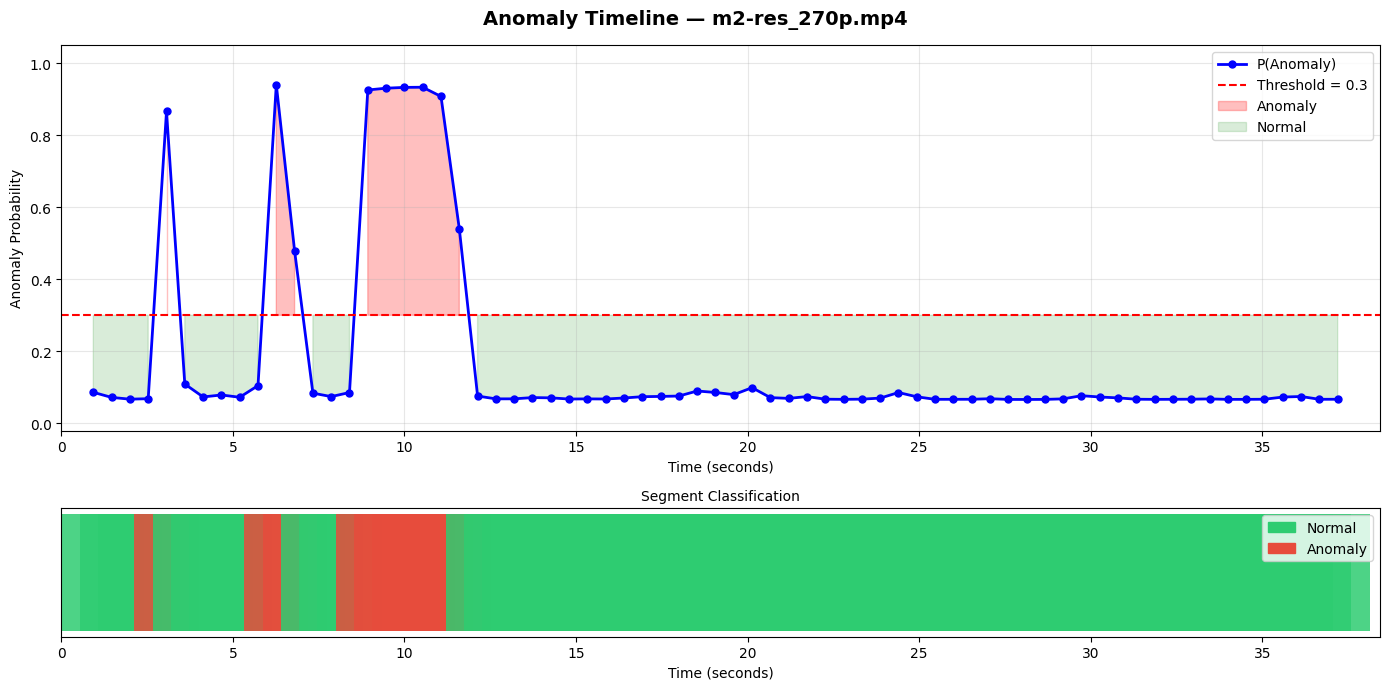

📊 Saved → ./anomaly_timeline.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Score every window of SEGMENT_CLIPS consecutive clips
seg_results = []
step = max(1, SEGMENT_CLIPS // 2)   # 50% overlap between windows
N    = len(features)

for start in range(0, N - SEGMENT_CLIPS + 1, step):
    end      = min(start + SEGMENT_CLIPS, N)
    seg_feat = features[start:end]
    res      = predict_features(seg_feat, model)
    t_start  = clip_times[start]
    t_end    = clip_times[end - 1] + (CLIP_LEN * FRAME_SKIP / fps)
    seg_results.append((t_start, t_end, res['prob_anomaly']))

# If video is very short (fewer clips than SEGMENT_CLIPS)
if len(seg_results) == 0:
    seg_results.append((0, duration_s, result['prob_anomaly']))

seg_starts = [s[0] for s in seg_results]
seg_ends   = [s[1] for s in seg_results]
seg_scores = [s[2] for s in seg_results]
seg_mids   = [(a + b) / 2 for a, b in zip(seg_starts, seg_ends)]

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(f'Anomaly Timeline — {os.path.basename(VIDEO_PATH)}',
             fontsize=14, fontweight='bold')

# Score line
ax = axes[0]
ax.plot(seg_mids, seg_scores, 'b-o', ms=5, lw=2, label='P(Anomaly)')
ax.axhline(y=THRESHOLD, color='red', linestyle='--', lw=1.5,
           label=f'Threshold = {THRESHOLD}')
ax.fill_between(seg_mids, seg_scores, THRESHOLD,
                where=[s >= THRESHOLD for s in seg_scores],
                color='red',   alpha=0.25, label='Anomaly')
ax.fill_between(seg_mids, seg_scores, THRESHOLD,
                where=[s < THRESHOLD for s in seg_scores],
                color='green', alpha=0.15, label='Normal')
ax.set_xlim(0, duration_s)
ax.set_ylim(-0.02, 1.05)
ax.set_ylabel('Anomaly Probability')
ax.set_xlabel('Time (seconds)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Colour bar
ax2 = axes[1]
for (ts, te, score) in seg_results:
    c = '#e74c3c' if score >= THRESHOLD else '#2ecc71'
    ax2.barh(0, te - ts, left=ts, height=0.6, color=c, alpha=0.85)
ax2.set_xlim(0, duration_s)
ax2.set_yticks([])
ax2.set_xlabel('Time (seconds)')
ax2.set_title('Segment Classification', fontsize=10)
ax2.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Normal'),
    mpatches.Patch(color='#e74c3c', label='Anomaly')
], loc='upper right')

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'artifacts' / 'reports' / 'anomaly_timeline.png'), dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved → ./anomaly_timeline.png')

## Cell 9 — Frame Grid with Scores

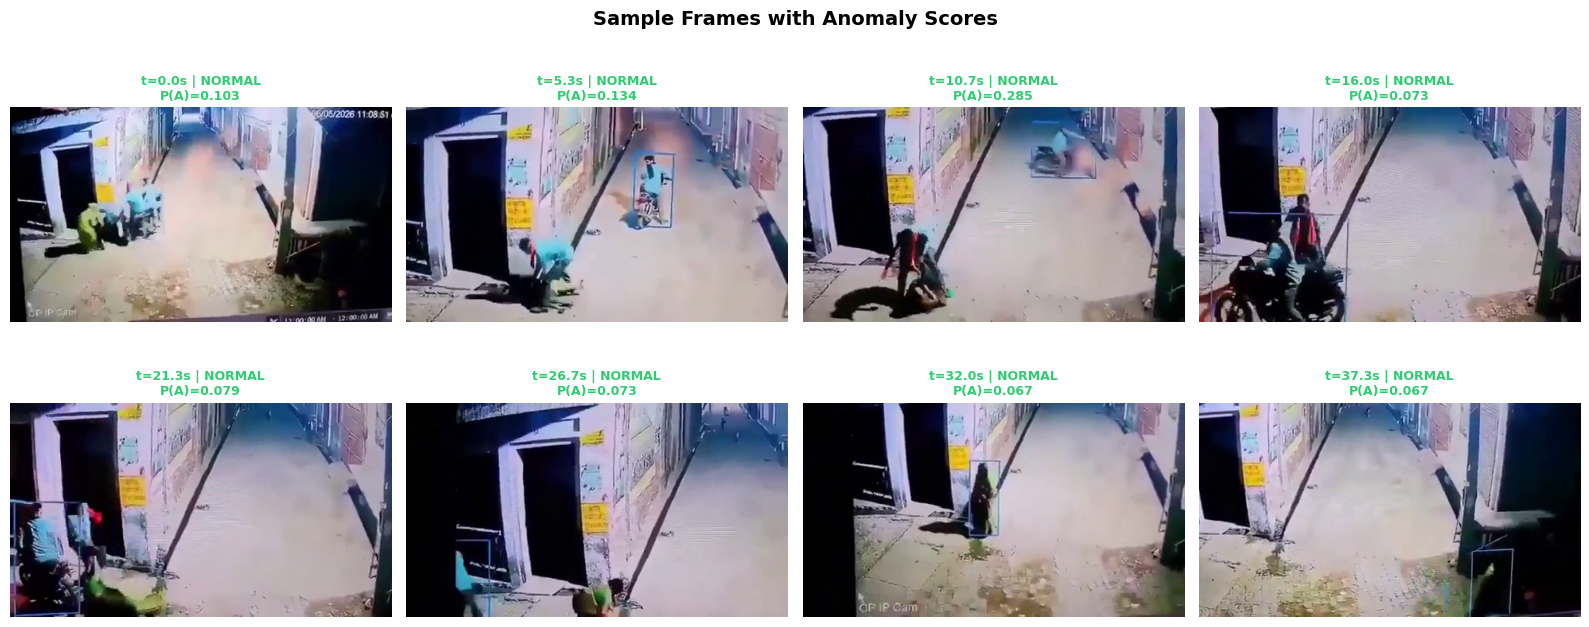

📸 Saved → ./sample_frames.png


In [10]:
N_SHOW  = min(8, len(clips))
indices = np.linspace(0, len(clips) - 1, N_SHOW, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Sample Frames with Anomaly Scores', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, ci in enumerate(indices):
    clip_frames, start_idx = clips[ci]
    t      = start_idx / fps
    score  = features[ci:ci+1]   # single clip feature
    res    = predict_features(features[ci:ci+1], model)
    label  = res['prediction']
    prob   = res['prob_anomaly']
    color  = '#e74c3c' if label == 'ANOMALY' else '#2ecc71'

    ax = axes[i]
    ax.imshow(clip_frames[CLIP_LEN // 2])    # middle frame of clip
    ax.set_title(f't={t:.1f}s | {label}\nP(A)={prob:.3f}',
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'artifacts' / 'reports' / 'sample_frames.png'), dpi=120, bbox_inches='tight')
plt.show()
print('📸 Saved → ./sample_frames.png')

## Cell 10 — Full Report

In [11]:
anomaly_segs = [(s, e, sc) for s, e, sc in seg_results if sc >= THRESHOLD]
anomaly_time = sum(e - s for s, e, sc in anomaly_segs)
peak_score   = max(seg_scores)
peak_time    = seg_mids[int(np.argmax(seg_scores))]

print('=' * 52)
print('  📋  ANOMALY DETECTION REPORT')
print('=' * 52)
print(f'  Video            : {os.path.basename(VIDEO_PATH)}')
print(f'  Duration         : {duration_s:.1f}s')
print(f'  Clips analysed   : {len(clips)}')
print(f'  Segments scored  : {len(seg_results)}')
print()
icon = '🔴' if result["prediction"] == 'ANOMALY' else '🟢'
print(f'  {icon} Overall Result  : {result["prediction"]}  ({result["confidence"]*100:.1f}% confidence)')
print(f'     P(Anomaly)    : {result["prob_anomaly"]*100:.1f}%')
print(f'     P(Normal)     : {result["prob_normal"]*100:.1f}%')
print()
print(f'  Anomaly segments : {len(anomaly_segs)} / {len(seg_results)}')
print(f'  Anomaly duration : {anomaly_time:.1f}s / {duration_s:.1f}s')
print(f'  Peak score       : {peak_score:.3f}  @ t={peak_time:.1f}s')

if anomaly_segs:
    print(f'\n  ⚠️  Anomaly detected at:')
    for s, e, sc in anomaly_segs:
        print(f'      {s:5.1f}s – {e:5.1f}s   (P={sc:.3f})')
else:
    print('\n  ✅ No anomaly intervals detected')
    print(f'     Try lowering THRESHOLD below {THRESHOLD} in Cell 2')
print('=' * 52)

  📋  ANOMALY DETECTION REPORT
  Video            : m2-res_270p.mp4
  Duration         : 38.4s
  Clips analysed   : 141
  Segments scored  : 69

  🟢 Overall Result  : NORMAL  (91.2% confidence)
     P(Anomaly)    : 8.8%
     P(Normal)     : 91.2%

  Anomaly segments : 9 / 69
  Anomaly duration : 16.8s / 38.4s
  Peak score       : 0.940  @ t=6.3s

  ⚠️  Anomaly detected at:
        2.1s –   4.0s   (P=0.866)
        5.3s –   7.2s   (P=0.940)
        5.9s –   7.7s   (P=0.479)
        8.0s –   9.9s   (P=0.925)
        8.5s –  10.4s   (P=0.930)
        9.1s –  10.9s   (P=0.932)
        9.6s –  11.5s   (P=0.933)
       10.1s –  12.0s   (P=0.907)
       10.7s –  12.5s   (P=0.540)
